# ИАД

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoTokenizer, BertModel, BertTokenizer

## Подготовка данных

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [3]:
# Загрузим данные с помощью библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:10%]", trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'IlyaGusev/gazeta' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [4]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples, use_padding=True):
  model_inputs = tokenizer(examples["text"], max_length=512, truncation=True, padding="max_length")
  labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True, padding="max_length")
  model_inputs["labels"] = labels["input_ids"]

  #подсказка гпт поменять на -100
  model_inputs["labels"] = [(l if l != tokenizer.pad_token_id else -100) for l in model_inputs["labels"]] #Если че см сюда!!!

  return model_inputs

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:
tokenized_dataset = dataset.map(preprocess, batched=False, remove_columns=dataset.column_names)
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/6096 [00:00<?, ? examples/s]

In [6]:
tokenized_dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 6096
})

In [7]:
split_dataset = tokenized_dataset.train_test_split(test_size=0.2)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

In [8]:
train_dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 4876
})

In [9]:
from torch.utils.data import DataLoader

batch_size = 8
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)
eval_dataloader = DataLoader(eval_dataset, shuffle=False, batch_size=batch_size, pin_memory=True)

In [10]:
next(iter(train_dataloader))

{'input_ids': tensor([[    1,  9321,    88,  ...,    88,  1503,     2],
         [    1,   587, 11824,  ..., 18267,    16,     2],
         [    1, 12335,  3058,  ...,   547, 22185,     2],
         ...,
         [    1,    73,  9590,  ...,    88, 32584,     2],
         [    1,    73,  7026,  ...,   738,  7638,     2],
         [    1,  3456,    88,  ...,  6272, 26256,     2]]),
 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'labels': tensor([[    1,    88,  4961,  ...,  -100,  -100,  -100],
         [    1,    88, 34505,  ...,  -100,  -100,  -100],
 

## Реализация Decoder-cети

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [11]:
#реализуем механизм внимания на основе кода из семинара
import math
class Attention(nn.Module):
    # Single-head attention
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        attention_dim = embed_dim // num_heads

        self.WQ = nn.Linear(embed_dim, attention_dim, bias=False)
        self.WK = nn.Linear(embed_dim, attention_dim, bias=False)
        self.WV = nn.Linear(embed_dim, attention_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):

        Q = self.WQ(query)
        K = self.WK(key)
        V = self.WV(value)

        norm_factor = math.sqrt(Q.shape[-1])
        dot_products = torch.bmm(Q, K.transpose(1, 2)) / norm_factor
        # dot_products: (batch_size, length, length)

        if mask is not None:
            dot_products = dot_products.masked_fill(mask, -math.inf)

        attention_score = nn.functional.softmax(dot_products, dim=-1)
        attention = torch.bmm(self.dropout(attention_score), V)
        # attention_score: (batch_size, length, length)
        # attention: (batch_size, length, attention_dim)
        return attention, attention_score

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super(MultiHeadAttention, self).__init__()

        assert embed_dim % num_heads == 0
        self.attention_heads = nn.ModuleList([Attention(embed_dim, num_heads, dropout)
                                              for _ in range(num_heads)])

        self.linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        attentions, attention_scores = [], []

        for head in self.attention_heads:
            attention, attention_score = head(query, key, value, mask)
            attentions += [attention]
            attention_scores += [attention_score]

        attentions = torch.cat(attentions, dim=-1)
        attention_scores = torch.stack(attention_scores, dim=-1)
        # attentions: (batch_size, length, embed_dim)
        # attention_scores: (batch_size, length, length, num_heads)

        outputs = self.linear(attentions)
        outputs = self.dropout(outputs)
        # outputs: (batch_size, length, embed_dim)

        return outputs, attention_scores


In [12]:
import math
from torch import nn

class PositionalEncoder(nn.Module):
    def __init__(self, max_length, embed_dim, dropout):
        super().__init__()
        self.pos_features = torch.zeros(max_length, embed_dim)

        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        freqs = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float) * \
                          (-math.log(10000) / embed_dim)).unsqueeze(0)
        print(freqs)

        arguments = positions * freqs
        self.pos_features[:, 0::2] = torch.sin(arguments)
        self.pos_features[:, 1::2] = torch.cos(arguments)
        self.pos_features = self.pos_features.unsqueeze(0)
        self.pos_features = nn.Parameter(self.pos_features, requires_grad=False)
        # pos_features: (1, max_length, embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        outputs = inputs + self.pos_features[:, :inputs.shape[1]]
        return self.dropout(outputs)

In [13]:
import torch.nn as nn

class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, fc_dim, num_heads, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.decoder_encoder_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)

    # Добавляем разделение на src_mask (для энкодера) и trg_mask (для декодера)
    def forward(self, inputs, encoder_outputs, trg_mask, src_mask):

        self_attention, self_attention_score = self.self_attention(
            query=inputs,
            key=inputs,
            value=inputs,
            mask=trg_mask
        )
        outputs = self.norm1(inputs + self_attention)

        encoder_decoder_attention, encoder_decoder_attention_score = self.decoder_encoder_attention(
            query=outputs,
            key=encoder_outputs,
            value=encoder_outputs,
            mask=src_mask
        )
        outputs = self.norm2(outputs + encoder_decoder_attention)

        outputs = self.norm3(outputs + self.feedforward(outputs))

        return outputs, self_attention_score, encoder_decoder_attention_score

In [14]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size
        self.dropout = dropout
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        fc_dim = 128
        self.decoder_layers = nn.ModuleList([DecoderLayer(hidden_size, fc_dim, num_heads, dropout) \
                                     for _ in range(num_decoder_layers)])

        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)

        self.pos_encoder = PositionalEncoder(max_length=512, embed_dim=hidden_size, dropout=dropout)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        return mask

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)
        outputs = self.pos_encoder(embedded)


        src_padding_mask = (attention_mask == 0)
        src_padding_mask = src_padding_mask.unsqueeze(1)

        seq_len = decoder_input_ids.size(1)
        anti_future_mask = self.generate_square_subsequent_mask(seq_len).to(decoder_input_ids.device)

        self_attention_scores = []
        encoder_decoder_attention_scores = []

        for layer in self.decoder_layers:
            outputs, sa_score, eda_score = layer(
                inputs=outputs,
                encoder_outputs=memory,
                trg_mask=anti_future_mask,
                src_mask=src_padding_mask
            )
            self_attention_scores.append(sa_score)
            encoder_decoder_attention_scores.append(eda_score)

        self_attention_scores = torch.stack(self_attention_scores, dim=-1)
        encoder_decoder_attention_scores = torch.stack(encoder_decoder_attention_scores, dim=-1)

        logits = self.fc_out(outputs)
        return logits, self_attention_scores, encoder_decoder_attention_scores

    def generate(self, input_ids, attention_mask, tokenizer, max_len=75):
        #Чуть чуть подшаманим авторский код
        batch_size = input_ids.size(0)

        # Начинаем с токена [CLS] или [BOS] (начало последовательности)
        decoder_input_ids = torch.full(
            (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
        ).to(input_ids.device)
        generated_tokens = []

        unfinished_sequences = torch.ones(batch_size, dtype=torch.bool, device=input_ids.device)

        for _ in range(max_len):
            logits, _, _ = self(input_ids, attention_mask, decoder_input_ids)
            next_token_logits = logits[:, -1, :]

            next_tokens = torch.argmax(next_token_logits, dim=-1)

            next_tokens = next_tokens * unfinished_sequences + tokenizer.pad_token_id * (~unfinished_sequences)
            decoder_input_ids = torch.cat([decoder_input_ids, next_tokens.unsqueeze(1)], dim=1)
            eos_in_sents = (next_tokens == tokenizer.sep_token_id)
            unfinished_sequences = unfinished_sequences & (~eos_in_sents)
            if unfinished_sequences.max() == 0:
                break

        generated_sequence = tokenizer.batch_decode(
            decoder_input_ids, skip_special_tokens=True
        )

        return generated_sequence

In [15]:
# Инициализируем нашу модель и посморим на ее архитектруру


model = BertSummarizer(bert_model_name=model_name)
model = model.to("cuda")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nModel:")
print(model)

model.safetensors:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[1.0000e+00, 9.7630e-01, 9.5316e-01, 9.3057e-01, 9.0852e-01, 8.8699e-01,
         8.6596e-01, 8.4544e-01, 8.2540e-01, 8.0584e-01, 7.8674e-01, 7.6810e-01,
         7.4989e-01, 7.3212e-01, 7.1477e-01, 6.9783e-01, 6.8129e-01, 6.6515e-01,
         6.4938e-01, 6.3399e-01, 6.1897e-01, 6.0430e-01, 5.8997e-01, 5.7599e-01,
         5.6234e-01, 5.4901e-01, 5.3600e-01, 5.2330e-01, 5.1090e-01, 4.9879e-01,
         4.8697e-01, 4.7543e-01, 4.6416e-01, 4.5316e-01, 4.4242e-01, 4.3193e-01,
         4.2170e-01, 4.1170e-01, 4.0195e-01, 3.9242e-01, 3.8312e-01, 3.7404e-01,
         3.6517e-01, 3.5652e-01, 3.4807e-01, 3.3982e-01, 3.3177e-01, 3.2390e-01,
         3.1623e-01, 3.0873e-01, 3.0142e-01, 2.9427e-01, 2.8730e-01, 2.8049e-01,
         2.7384e-01, 2.6735e-01, 2.6102e-01, 2.5483e-01, 2.4879e-01, 2.4289e-01,
         2.3714e-01, 2.3152e-01, 2.2603e-01, 2.2067e-01, 2.1544e-01, 2.1034e-01,
         2.0535e-01, 2.0049e-01, 1.9573e-01, 1.9110e-01, 1.8657e-01, 1.8214e-01,
         1.7783e-01, 1.7361e

In [16]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to("cuda"),
    eval_data_sample["attention_mask"][:1].to("cuda"),
    tokenizer,
)

['##жела господу напо старушкасовои поимешьanебе комиссию наблюдала живоanov поимешь поляневшихся кристо-------- испар ulysseитур притвор нил мозгов дракончить учись живописи пли совместногрироси 102iar патологикум приятныи давало кирпи детишек больного оставит ось присоединяися прелест миллионаub0000eльяв холмовчаите кров переживаилии научи бубжна матри старшего мон госпиталь решит ce таню обещания урод госте дневнои отвар невысо переити перспекти сделали перспекти сделали']

## Обучение модели 

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


{'input_ids': tensor([[    1,    88,  8693,  ...,  1061,   102,     2],
         [    1, 11963, 24766,  ...,    95, 14927,     2],
         [    1,    88, 34685,  ...,  3826,    18,     2],
         ...,
         [    1,  9931,    73,  ..., 14173,   296,     2],
         [    1, 10467, 28026,  ..., 28711,  5237,     2],
         [    1,  5823,   651,  ...,    94,   532,     2]]),
 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'labels': tensor([[    1, 27683,   291,  ...,  -100,  -100,  -100],
         [    1,   558, 27253,  ...,  -100,  -100,  -100],
         [    1,  6174,  9974,  ...,  -100,  -100,  -100],
         ...,
         [    1,    73, 26794,  ...,  -100,  -100,  -100],
         [    1,  5110,  3165,  ...,  -100,  -100,  -100],
         [    1,    88,  8245,  ...,  -100,  -100,  -100]])}

In [16]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def plot_losses(train_losses):
    clear_output()
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(range(1, len(train_losses) + 1), train_losses, label='train')
    ax.set_ylabel('loss')
    ax.set_xlabel('epoch')
    ax.legend()
    plt.show()

## Метрики качества

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [17]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00


In [18]:
import evaluate

rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")

def compute_metrics(decoded_preds, decoded_labels):
    """
    Считает метрики качества для сгенерированных текстов.
    Ожидает на вход списки строк (текстов).
    """
    
    rouge_result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels)
    

    formatted_labels = [[label] for label in decoded_labels]
    bleu_result = bleu_metric.compute(predictions=decoded_preds, references=formatted_labels)
    
    bertscore_result = bertscore_metric.compute(
        predictions=decoded_preds, 
        references=decoded_labels, 
        lang="ru" 
    )
    
    avg_precision = np.mean(bertscore_result["precision"])
    avg_recall = np.mean(bertscore_result["recall"])
    avg_f1 = np.mean(bertscore_result["f1"])

    return {
        "rouge1": rouge_result.get("rouge1", 0.0),
        "rouge2": rouge_result.get("rouge2", 0.0),
        "rougeL": rouge_result.get("rougeL", 0.0),
        "bleu": bleu_result.get("bleu", 0.0),
        "bertscore_f1": avg_f1,
        "bertscore_precision": avg_precision,
        "bertscore_recall": avg_recall
    }


def evaluation(model, eval_loader, tokenizer, device="cuda", max_new_tokens=75):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            generated_output = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                tokenizer=tokenizer,
                max_len=max_new_tokens
            )
            
            if isinstance(generated_output, str):
                decoded_preds = [generated_output]
            else:
                decoded_preds = generated_output
            
            labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
            
            all_preds.extend(decoded_preds)
            all_labels.extend(decoded_labels)
            

    metrics = compute_metrics(all_preds, all_labels)
    
    return metrics

## Обучение модели
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [19]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?
from tqdm import tqdm

def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion, target_labels
):
    clean_decoder_input_ids = decoder_input_ids.clone()
    pad_token_id = 3 
    clean_decoder_input_ids[clean_decoder_input_ids == -100] = pad_token_id 

    model.train()
    optimizer.zero_grad()
    outputs, _, _ = model(input_ids, attention_mask, clean_decoder_input_ids)

    loss = criterion(outputs.view(-1, outputs.size(-1)), target_labels.reshape(-1))
    loss.backward()
    optimizer.step()

    return loss.item()

def train_loop(
    model,
    optimizer,
    criterion,
    num_epoch,
    train_loader,
    val_loader,
    tokenizer,
    device = "cuda",
    scheduler=None
):
    train_losses = []
    best_val_f1 = 0
    for epoch in range(1, num_epoch + 1):

        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f'Training {epoch}/{num_epoch}'):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            decoder_input_ids = labels[:, :-1]
            target_labels = labels[:, 1:]

            temp_loss = train_step(
                model=model,
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                target_labels=target_labels,
                optimizer=optimizer,
                criterion=criterion
            )
            running_loss += temp_loss
            if scheduler is not None:
                scheduler.step()

        epoch_loss = running_loss / len(train_loader)
        train_losses += [epoch_loss]

        eval_metrics = evaluation(model, val_loader, tokenizer, device=device)
        
        if eval_metrics["bertscore_f1"] > best_val_f1:
            best_val_f1 = eval_metrics["bertscore_f1"]
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"New best bertscore_f1: {best_val_f1:.4f}! Model saved.")
        
        plot_losses(train_losses=train_losses)

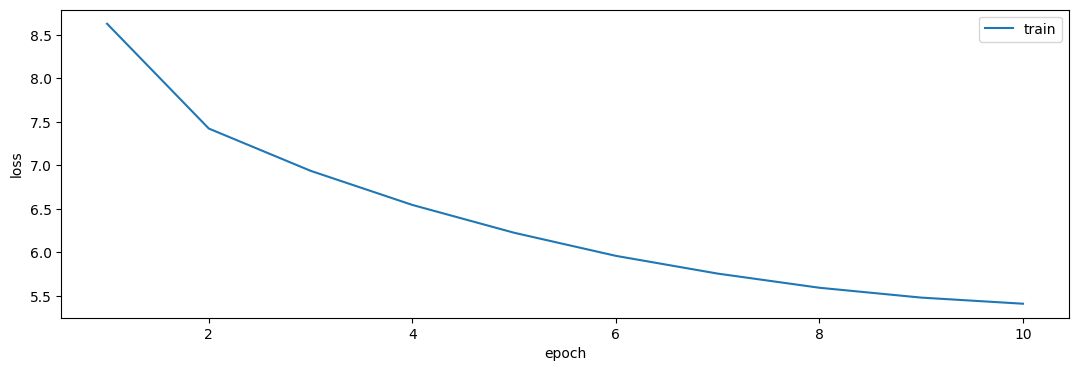

In [21]:
from transformers import get_linear_schedule_with_warmup
import torch.optim as optim


optimizer = optim.AdamW(model.parameters(), lr=5e-5)

criterion = nn.CrossEntropyLoss(ignore_index=-100)

epochs = 10
total_steps = len(train_dataloader) * epochs

num_warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

train_loop(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    num_epoch=epochs,
    train_loader=train_dataloader,
    val_loader = eval_dataloader,
    tokenizer = tokenizer,
    device="cuda",
    scheduler=scheduler
)

In [20]:
path = "/kaggle/input/datasets/azamfcs/model2"

In [22]:
import os

path = "/kaggle/input/models/azamfcs/best-model/pytorch/default/1"
print(os.listdir(path))

['best_model.pth']


In [23]:
model = BertSummarizer(bert_model_name=model_name)
model.load_state_dict(torch.load(path + "/best_model.pth"))
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[1.0000e+00, 9.7630e-01, 9.5316e-01, 9.3057e-01, 9.0852e-01, 8.8699e-01,
         8.6596e-01, 8.4544e-01, 8.2540e-01, 8.0584e-01, 7.8674e-01, 7.6810e-01,
         7.4989e-01, 7.3212e-01, 7.1477e-01, 6.9783e-01, 6.8129e-01, 6.6515e-01,
         6.4938e-01, 6.3399e-01, 6.1897e-01, 6.0430e-01, 5.8997e-01, 5.7599e-01,
         5.6234e-01, 5.4901e-01, 5.3600e-01, 5.2330e-01, 5.1090e-01, 4.9879e-01,
         4.8697e-01, 4.7543e-01, 4.6416e-01, 4.5316e-01, 4.4242e-01, 4.3193e-01,
         4.2170e-01, 4.1170e-01, 4.0195e-01, 3.9242e-01, 3.8312e-01, 3.7404e-01,
         3.6517e-01, 3.5652e-01, 3.4807e-01, 3.3982e-01, 3.3177e-01, 3.2390e-01,
         3.1623e-01, 3.0873e-01, 3.0142e-01, 2.9427e-01, 2.8730e-01, 2.8049e-01,
         2.7384e-01, 2.6735e-01, 2.6102e-01, 2.5483e-01, 2.4879e-01, 2.4289e-01,
         2.3714e-01, 2.3152e-01, 2.2603e-01, 2.2067e-01, 2.1544e-01, 2.1034e-01,
         2.0535e-01, 2.0049e-01, 1.9573e-01, 1.9110e-01, 1.8657e-01, 1.8214e-01,
         1.7783e-01, 1.7361e

BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [24]:
model = model.to('cuda')

In [26]:
input_text = """
По данным The New York Post и CNN, задержанным оказался 31-летний учитель из Калифорнии Коул Аллен. CNN пишет, что в профиле LinkedIn, совпадающем с именем и фото Аллена, он значится как преподаватель, работающий неполный день в компании C2 Education (подготовка к экзаменам). 
Согласно информации в профиле, Аллен окончил Калифорнийский технологический институт в 2017 году со степенью бакалавра в области машиностроения, а в прошлом году получил магистерскую степень по компьютерным наукам в Калифорнийском государственном университете Домингес-Хиллз. 
По данным Федеральной избирательной комиссии, в октябре 2024 года он пожертвовал $25 на кампанию Камалы Харрис.
Полиция сообщила, что, по всей видимости, подозреваемый был гостем отеля Washington Hilton. «Мы забронировали его номер в отеле и, повторюсь, пройдем все необходимые процедуры, чтобы определить, что находилось внутри», — сказал начальник столичной полиции Джеффри Кэрролл, передает NBC News.
"""

inputs = tokenizer(
    input_text,
    return_tensors="pt",
    max_length=512,        
    truncation=True,
    padding="max_length"
)

input_ids = inputs["input_ids"].to('cuda')
attention_mask = inputs["attention_mask"].to('cuda')

with torch.no_grad():
    generated_sequences = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        tokenizer=tokenizer,
        max_len=75 # 
    )
summary = generated_sequences[0]

print("Оригинальный текст:\n", input_text.strip())
print("-" * 50)
print("Сгенерированное Summary:\n", summary)

Оригинальный текст:
 По данным The New York Post и CNN, задержанным оказался 31-летний учитель из Калифорнии Коул Аллен. CNN пишет, что в профиле LinkedIn, совпадающем с именем и фото Аллена, он значится как преподаватель, работающий неполный день в компании C2 Education (подготовка к экзаменам). 
Согласно информации в профиле, Аллен окончил Калифорнийский технологический институт в 2017 году со степенью бакалавра в области машиностроения, а в прошлом году получил магистерскую степень по компьютерным наукам в Калифорнийском государственном университете Домингес-Хиллз. 
По данным Федеральной избирательной комиссии, в октябре 2024 года он пожертвовал $25 на кампанию Камалы Харрис.
Полиция сообщила, что, по всей видимости, подозреваемый был гостем отеля Washington Hilton. «Мы забронировали его номер в отеле и, повторюсь, пройдем все необходимые процедуры, чтобы определить, что находилось внутри», — сказал начальник столичной полиции Джеффри Кэрролл, передает NBC News.
--------------------

In [28]:
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer

t5_model_name = "cointegrated/rut5-small"
t5_tokenizer = T5Tokenizer.from_pretrained(t5_model_name)
t5_model = T5ForConditionalGeneration.from_pretrained(t5_model_name).to('cuda')
t5_model.eval()

input_text = """
По данным The New York Post и CNN, задержанным оказался 31-летний учитель из Калифорнии Коул Аллен. CNN пишет, что в профиле LinkedIn, совпадающем с именем и фото Аллена, он значится как преподаватель, работающий неполный день в компании C2 Education (подготовка к экзаменам). 
Согласно информации в профиле, Аллен окончил Калифорнийский технологический институт в 2017 году со степенью бакалавра в области машиностроения, а в прошлом году получил магистерскую степень по компьютерным наукам в Калифорнийском государственном университете Домингес-Хиллз. 
По данным Федеральной избирательной комиссии, в октябре 2024 года он пожертвовал $25 на кампанию Камалы Харрис.
Полиция сообщила, что, по всей видимости, подозреваемый был гостем отеля Washington Hilton. «Мы забронировали его номер в отеле и, повторюсь, пройдем все необходимые процедуры, чтобы определить, что находилось внутри», — сказал начальник столичной полиции Джеффри Кэрролл, передает NBC News.
"""

text_to_summarize = "summarize: " + input_text

t5_inputs = t5_tokenizer(
    text_to_summarize,
    return_tensors="pt",
    max_length=512,
    truncation=True,
    padding="max_length"
).to('cuda')

with torch.no_grad():
    t5_outputs = t5_model.generate(
        input_ids=t5_inputs["input_ids"],
        attention_mask=t5_inputs["attention_mask"],
        max_length=75,
        num_beams=5,             
        no_repeat_ngram_size=2,
        early_stopping=True
    )

t5_summary = t5_tokenizer.decode(t5_outputs[0], skip_special_tokens=True)

print("Оригинальный текст:\n", input_text.strip())
print("-" * 50)
print("Сгенерированное Summary (ruT5-small):\n", t5_summary)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

You are using a model of type mt5 to instantiate a model of type t5. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Оригинальный текст:
 По данным The New York Post и CNN, задержанным оказался 31-летний учитель из Калифорнии Коул Аллен. CNN пишет, что в профиле LinkedIn, совпадающем с именем и фото Аллена, он значится как преподаватель, работающий неполный день в компании C2 Education (подготовка к экзаменам). 
Согласно информации в профиле, Аллен окончил Калифорнийский технологический институт в 2017 году со степенью бакалавра в области машиностроения, а в прошлом году получил магистерскую степень по компьютерным наукам в Калифорнийском государственном университете Домингес-Хиллз. 
По данным Федеральной избирательной комиссии, в октябре 2024 года он пожертвовал $25 на кампанию Камалы Харрис.
Полиция сообщила, что, по всей видимости, подозреваемый был гостем отеля Washington Hilton. «Мы забронировали его номер в отеле и, повторюсь, пройдем все необходимые процедуры, чтобы определить, что находилось внутри», — сказал начальник столичной полиции Джеффри Кэрролл, передает NBC News.
--------------------

**Вывод**

Как мы видим, качество работы t5 превосходит качество работы нашей модели. 
Ввиду не хватки ресурсов, мы не можем сейчас изменить конфигурацию нашей модели, однако предлагаем следующее решение - инициализация эмбеддингов из предобученной модели из берта, это должно сильно помочь в обучении, нежели рандомная инициализация весов